<a href="https://colab.research.google.com/github/Dreeck/ProyectosML/blob/Proyecto2/Semillas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix


In [ ]:
uploaded = files.upload()


Saving seeds_dataset.txt to seeds_dataset (1).txt


In [ ]:
!head -n 10 seeds_dataset.txt  # Mostrar las primeras 10 líneas del archivo


15.26	14.84	0.871	5.763	3.312	2.221	5.22	1
14.88	14.57	0.8811	5.554	3.333	1.018	4.956	1
14.29	14.09	0.905	5.291	3.337	2.699	4.825	1
13.84	13.94	0.8955	5.324	3.379	2.259	4.805	1
16.14	14.99	0.9034	5.658	3.562	1.355	5.175	1
14.38	14.21	0.8951	5.386	3.312	2.462	4.956	1
14.69	14.49	0.8799	5.563	3.259	3.586	5.219	1
14.11	14.1	0.8911	5.42	3.302	2.7		5		1
16.63	15.46	0.8747	6.053	3.465	2.04	5.877	1
16.44	15.25	0.888	5.884	3.505	1.969	5.533	1


In [ ]:
# Definir los nombres de las columnas
columnas = [
    'area',
    'perimetro',
    'compacidad',
    'longitud_nucleo',
    'ancho_nucleo',
    'coeficiente_asimetria',
    'longitud_surco',
    'clase'
]

# Leer el archivo subido
datos = pd.read_csv('seeds_dataset.txt', sep='\s+', names=columnas, engine='python')

# Mostrar las primeras filas
datos.head(10)


,area,perimetro,compacidad,longitud_nucleo,ancho_nucleo,coeficiente_asimetria,longitud_surco,clase
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
5,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,1
6,14.69,14.49,0.8799,5.563,3.259,3.586,5.219,1
7,14.11,14.10,0.8911,5.420,3.302,2.700,5.000,1
8,16.63,15.46,0.8747,6.053,3.465,2.040,5.877,1
9,16.44,15.25,0.8880,5.884,3.505,1.969,5.533,1


In [ ]:
display(datos.head(10))

,area,perimetro,compacidad,longitud_nucleo,ancho_nucleo,coeficiente_asimetria,longitud_surco,clase
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
5,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,1
6,14.69,14.49,0.8799,5.563,3.259,3.586,5.219,1
7,14.11,14.10,0.8911,5.420,3.302,2.700,5.000,1
8,16.63,15.46,0.8747,6.053,3.465,2.040,5.877,1
9,16.44,15.25,0.8880,5.884,3.505,1.969,5.533,1


In [ ]:
# Separar características X y etiquetas y
X = datos.drop('clase', axis=1)
y = datos['clase']  # Etiquetas = 1: Kama, 2: Rosa, 3: Canadiense

# Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


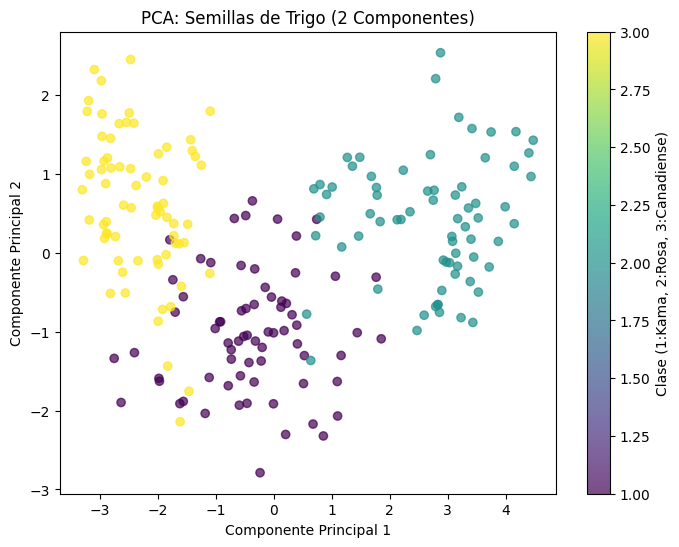

In [ ]:
# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Graficar
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.title('PCA: Semillas de Trigo (2 Componentes)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(label='Clase (1:Kama, 2:Rosa, 3:Canadiense)')
plt.show()

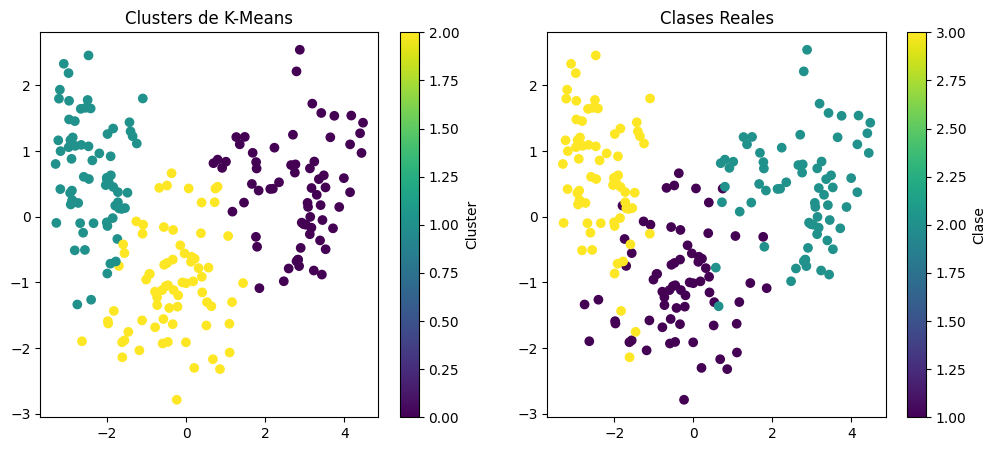

In [ ]:
# Aplicar K-Means (k=3, sabemos que hay 3 clases)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Graficar clusters vs clases reales
plt.figure(figsize=(12, 5))

# Subplot 1: Clusters encontrados
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title('Clusters de K-Means')
plt.colorbar(label='Cluster')

# Subplot 2: Clases reales
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.title('Clases Reales')
plt.colorbar(label='Clase')
plt.show()


In [ ]:
# Mide la similitud entre clusters y clases reales
ari = adjusted_rand_score(y, clusters)
print(f"Adjusted Rand Index: {ari:.2f}")

Adjusted Rand Index: 0.80


In [ ]:
# Centroides en escala original
centroides = scaler.inverse_transform(kmeans.cluster_centers_)
centroides_df = pd.DataFrame(centroides, columns=X.columns)
centroides_df['cluster'] = ['Cluster1', 'Cluster2', 'Cluster3']

print("Centroides de los clusters (valores originales):")
display(centroides_df)

# Comparar con medias reales por clase
print("\nMedias reales por clase:")
display(datos.groupby('clase').mean())


Centroides de los clusters (valores originales):


,area,perimetro,compacidad,longitud_nucleo,ancho_nucleo,coeficiente_asimetria,longitud_surco,cluster
0,18.449559,16.184265,0.884010,6.171397,3.691221,3.644574,6.038074,Cluster1
1,11.832609,13.244928,0.846901,5.235203,2.841913,4.784826,5.110420,Cluster2
2,14.341918,14.287945,0.881655,5.494630,3.249479,2.726825,5.102562,Cluster3



Medias reales por clase:


,area,perimetro,compacidad,longitud_nucleo,ancho_nucleo,coeficiente_asimetria,longitud_surco
clase,,,,,,,
1,14.334429,14.294286,0.880070,5.508057,3.244629,2.667403,5.087214
2,18.334286,16.135714,0.883517,6.148029,3.677414,3.644800,6.020600
3,11.873857,13.247857,0.849409,5.229514,2.853771,4.788400,5.116400


Cluster1 (K-Means)tiene los valores promedio más altos. Se corresponde con la Clase 2 (Real)también muestra los valores promedio más altos en estas mismas características. Ambos tienen el mismo coeficiente de asimetría

Cluster2 (K-Means). Se corresponde con la Clase 3 (Real) Ambos presentan los valores promedio más bajos y el coeficiente_asimetria más alto


Cluster3 (K-Means) se corresponde con la Clase 1 (Real) ambos muestran valores intermedio pero el coeficiente de asimetría  más bajo

Esto proporciona una interpretación tangible de los clústeres en el contexto del problema de las semillas. Por ejemplo, la Clase 2 (Cluster1) se caracteriza por tener las semillas más grandes en área y perímetro, mientras que la Clase 3 (Cluster2) tiene las semillas más pequeñas y asimétricas.